# Gletsjer

# Skriv intro her, relater til pdf

Før vi går i gang, skal vi have hentet nogle "pakker". Tænk på det som nogen der har skrevet noget kode vi kan importere, så vi ikke skal gøre alting fra bunden. Når du kører cellen herunder, importerer og installerer den automatisk det vi skal bruge.

In [91]:
# Importer pakker der skal bruges
%pip install -q numpy matplotlib scikit-learn lightgbm graphviz ipython scipy

# Data
import numpy as np
import scipy as scipy

# Plotting
import matplotlib.pyplot as plt

# Sklearn: et librabry med en masse funtioner vi bruger i Machine Learning
import sklearn as sklearn

# Graphviz - Pakke der kan visualisere decision trees
from IPython.display import SVG, display
from graphviz import Source

# LightGBM - pakke til at køre decision tree
import lightgbm as lgb
from lightgbm import early_stopping

Note: you may need to restart the kernel to use updated packages.


## Inspicer dataen

Først vil vi gerne undersøge hvilken data vi har med at gøre. 

In [92]:
data = np.genfromtxt("gletsjer_data_rounded.csv",
 delimiter=',', names=True, dtype=None, encoding=None)

variabler = data.dtype.names
input_variabler = [v for v in variabler if v != 'gletsjer_dybde']
input_data = np.column_stack([data[v] for v in input_variabler])
truth_data = data['gletsjer_dybde']

# Print first 5 rows with names
print(" | ".join(variabler))
for row in data[:5]:
    print(" | ".join(str(row[v]) for v in variabler))

haeldning_300m | elevation | mass_balance | haeldning_adaptiv | hastighed_x | retning | hastighed_y | afstand_til_kant_km | areal | gletsjer_dybde
0.14 | 220.65 | -485.22 | 0.27 | 1.13 | 281.93 | -6.67 | 0.027 | 0.082 | 6.0
0.14 | 216.72 | -489.38 | 0.27 | 1.13 | 296.14 | -6.67 | 0.018 | 0.082 | 11.0
0.12 | 142.2 | -568.2 | 0.16 | 1.71 | 312.49 | -7.02 | 0.01 | 0.082 | 13.0
0.12 | 141.34 | -569.11 | 0.15 | 1.71 | 312.77 | -7.02 | 0.012 | 0.082 | 7.0
0.14 | 219.96 | -485.96 | 0.27 | 1.13 | 260.25 | -6.67 | 0.029 | 0.082 | 6.0


# Decision Tree

Et decision tree er bygget op af lag og grene. Ved hver gren stiller den et spørgsmål, og bevæger sig ned i det næste lag baseret på om spørgsmålet er sandt eller falsk. Og ved at lære af en masse data, kan den finde ud af hvilke spørgsmål der er bedst at stille.

### Parameter
For et decision tree kan vi justere på hvor mange lag der skal være i vores træ, altså hvor mange lag af spørgsmål der må stilles. Vi kan justere på den parameter herunder.

In [93]:
DT_N_lag = 2         # Hvor mange lag der er i træet

Her bygger og træner vi modellen og bruger Graphviz til at visualisere det.

Max dybde af træet: 2
Forskellige dybder den kan forudsige: 4


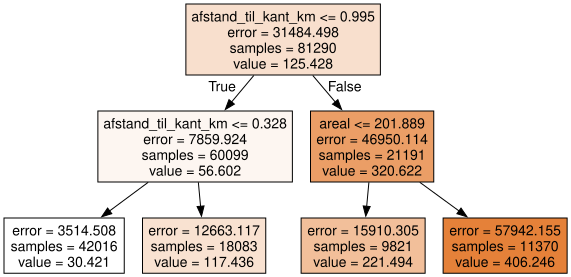

In [94]:
# Her bliver modellen trænet på data
estimator = sklearn.tree.DecisionTreeRegressor(max_depth=DT_N_lag, min_samples_leaf = 20,random_state=42)

estimator.fit(input_data, truth_data)   # Dette er den "magiske" linje - her optimerer Machine Learning algoritmen sine interne vægte til at give bedste svar

# laver visuel graf af træet
dot = sklearn.tree.export_graphviz(estimator, out_file=None, feature_names=input_variabler, filled=True, max_depth=50)         
dot = dot.replace("squared_error", "error").replace("mse", "error")
graph = Source(dot)
print("Max dybde af træet:", estimator.get_depth())
print("Forskellige dybder den kan forudsige:", np.unique(estimator.predict(input_data)).size)
display(SVG(graph.pipe(format='svg')))


### Spørgsmål:

- Inspicer træet. Forstår du/I, hvad de forskellige tal betyder?
  Hvad er gældende for gletsjerne i lag 2 og hvad er algortimens bud på deres dybde?
- Prøv at ændre på hvor mange lag der er i træet fra 2 til 3.
  Hvilken parameter bliver brugt oftest til at opdele data? Tror du/I at den så er den vigtigste parameter?
  Kan du/I ud fra træet sige mere generelt hvilke parametre der betyder mest for dybden? Hvilke betyder mindst?

## Boosted Decision Tree

Nu hvor vi har set hvordan træet virker, vil vi gerne prøve at forudsige værdien på gletsjere som vi ikke kender dybden på.
Som vi har set, kan det være svært at minimere vores 'loss function'. En måde at forbedre på er ved at køre boosted decision trees, hvilket vil sige at vi kører flere træer, hvor den hver gang lærer af fejlene fra det forrige træ, og på den måde bliver "boostet" for hvert træ den laver. Herunder kan vi ændre hvor mange gange den må "booste", altså hvor mange træer den må lave og lære af.

In [95]:
boosting_rounds = 1      # Hvor mange runder af træer den må lave og lærer af

Vi kan også vælge hvor stor en andel af data vi vil bruge. 

In [96]:
andel_af_data = 1.0  #Vælg hvor stor andel. Tallet skal være mellem 0 og 1.0.

#Vi omdefinerer vores input og truth data til kun at indeholde en del af dataene.
input_data_justeret, truth_data_justeret = sklearn.utils.resample(
    input_data, truth_data, 
    n_samples=int(andel_af_data * len(input_data)), 
    random_state=42, 
    replace=False
    )

Vi bruger train_test_split til at splitte data i et træningssæt og et testsæt.
Træningssættet bruges til at træne modellen, hvor modellen får de rigtige dybder at vide at vide.
Testsættet bruges til at give den trænede model data uden dybder, som den så skal forudsige, men hvor vi stadig kender svaret. Dette bruges til at evaluere modellens performance.

In [97]:
data_træning, data_test, sand_dybde_træning, sand_dybde_test = \
    sklearn.model_selection.train_test_split(input_data_justeret, truth_data_justeret, test_size=0.25, random_state=42)

In [98]:
# Her bygger vi modellen op med flere træer, træner på data og forudsiger dybder

gbm_test = lgb.LGBMRegressor( objective='regression', n_estimators=boosting_rounds, verbosity=-1)

gbm_test.fit(data_træning, sand_dybde_træning, eval_set=[(data_test, sand_dybde_test)], 
             eval_metric='mse', callbacks=[early_stopping(15)])

forudsagt_dybde = gbm_test.predict(data_test, num_iteration=gbm_test.best_iteration_)

Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[1]	valid_0's l2: 27665.3


In [99]:
# Denne function laver plots til at vise hvor godt algoritmen klarer sig.

def plotting(sand, forudsagt):

    r2 = sklearn.metrics.r2_score(sand, forudsagt) 
    MAE = sklearn.metrics.mean_absolute_error(sand, forudsagt)
    MSE = sklearn.metrics.mean_squared_error(sand, forudsagt)

    residuals = forudsagt - sand
    uncertainty = np.std(residuals)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    ###---- VENSTRE PLOT -----###
    ax = axes[0]
    ax.hist((forudsagt - sand), bins = 100)
    ax.text(0.02, 0.98, f"Usikkerhed: {uncertainty:,.2f} m.",
    transform=ax.transAxes, va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))
    ax.set_xlabel('Residual')
    ax.set_ylabel('counts')
    ax.set_title('Histogram residualer')

    ###---- HØJRE PLOT -----###
    ax = axes[1]
    ax.scatter(sand, forudsagt, alpha=0.3, s=10, label="Datapunkter")
    # Contour
    xy = np.vstack([sand, forudsagt])
    kde = scipy.stats.gaussian_kde(xy)
    xmin, xmax = np.min(sand), np.max(sand)
    ymin, ymax = np.min(forudsagt), np.max(forudsagt)
    xgrid, ygrid = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xgrid.ravel(), ygrid.ravel()])
    density = np.reshape(kde(positions).T, xgrid.shape)
    ax.contour(xgrid, ygrid, density, colors='k', linewidths=1, alpha=0.7)

    ax.plot([xmin, xmax], [xmin, xmax], 'r--', label='Perfekt forudsigelse')
    ax.grid(True)
    ax.set_ylabel('Forudsagt dybde (m)')
    ax.set_xlabel('Sand dybde (m)')
    ax.text(0.02, 0.98, f"MAE: {MAE:,.2f}\nMSE: {MSE:,.2f}\nR²: {r2:,.2f}",
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))
    ax.legend()
    ax.set_title('Sand vs forudsagt dybde')

    plt.tight_layout()
    plt.show()


Nu vil vi gerne inspicere hvor god vores model er til at forudsige på data hvor den ikke kender dybden i forvejen. Det venstre plot viser residualerne, altså (sand værdi - forudsagt værdi). Det højre plot er sand værdi vs forudsagt værdi. Her er også konturer (de sorte linjer), der viser tætheden af punkterne.



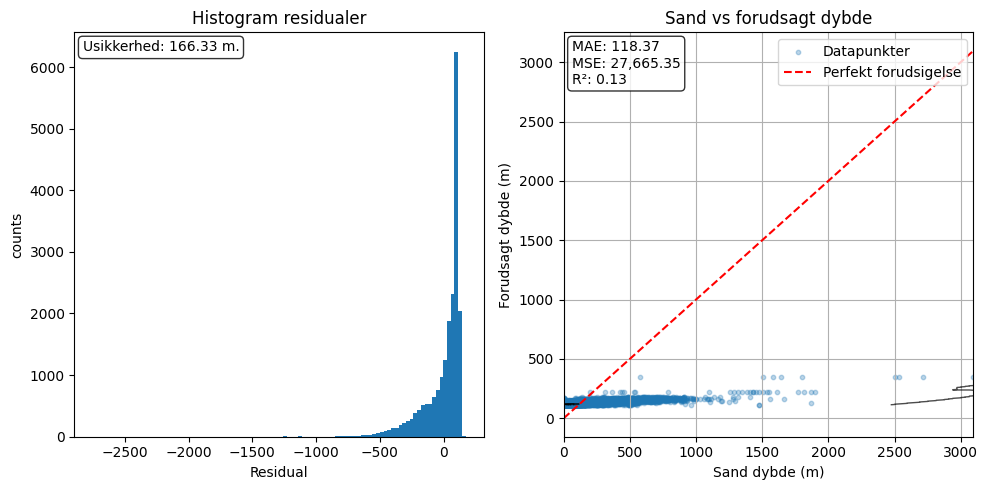

In [100]:
plotting(sand_dybde_test, forudsagt_dybde)

### Spørgsmål:

- Prøv at ændre på hvor mange gange gange den må booste, ved at ændre boosting_rounds fra 1 til 2 til 10, 100 eller 1000. Kan du se en forbedring?
- Hvilke gletsjere er der mest data på?
- Hvad gætter modellen på hvis ikke den før lov til at booste mange gange? Er der bestemte områder hvor modellen har sværere ved at forudsige dybden?
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?

### Hvilke variable er vigtigst?
Vi kan tjekke om vores intuition for hvilke variabler der er vigtigst med "permutation importance". Det er et mål for hvis værdierne i en kolonne bliver byttet rundt randomly, hvor meget påvirker det så resultatet. Hvis det er en vigtig variable, vil det påvirke resultatet meget. Her bliver det mål på hvor meget større mean squared error bliver, når den variabel bliver "scramblet".

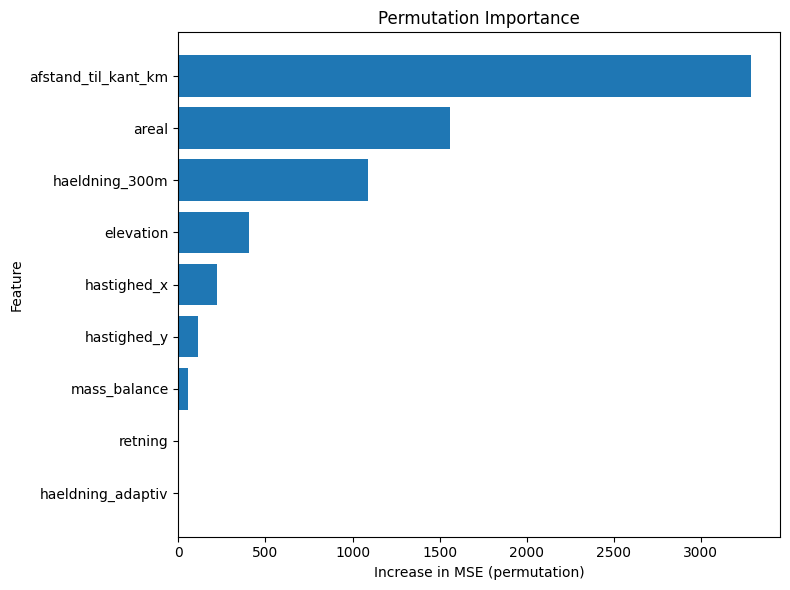

In [101]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")

res = sklearn.inspection.permutation_importance(gbm_test, data_test, sand_dybde_test, scoring="neg_mean_squared_error")

imp_mse = res.importances_mean                
order = np.argsort(imp_mse)[::-1]
labels = np.asarray(variabler[:-1])[order]
vals = imp_mse[order]

plt.figure(figsize=(8, 6))
y = np.arange(len(vals))
plt.barh(y, vals)
plt.yticks(y, labels)
plt.xlabel("Increase in MSE (permutation)")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

- Er resultatet som du forventede?
- Kan du give en mulig grund til hvorfor netop disse variable har størst betydning?


# Neurale Netværk

Neurale Netværk (NN) kommer fra at opbygningen af det, minder om den måde vores neuroner i hjernen snakker sammen på. På samme måde som et decision tree er der forskellige lag og vi kan styre hvor mange lag der er, men nu er det ikke kun sandt eller falsk, i stedet fungerer noderne som knapper der kan fintunes. 

Neurale netværk er mere følsomme overfor det data vi giver dem. Den fungerer bedst hvis resultatet er værdier mellem 0 og 1. Derfor bruger vi en funktion til at skalere vores data, kaldet StandardScaler:

In [102]:
scaler = sklearn.preprocessing.StandardScaler()

data_træning = scaler.fit_transform(data_træning)
data_test = scaler.transform(data_test)

I et neuralt netværk kan vi justere på hvor mange lag og hvor mange noder hvert lag skal have:

In [103]:
layer_one   = 32            # Her definerer vi hvor mange lag der skal være, og hvor mange 'neuroner' eller noder 
layer_two   = 16            # hvert lag skal have. Prøv at ændre på antal noder 
layer_three = 8             # for at forbedre din model
layer_four  = 4
layer_five  = 2
layer_six   = 2

Nedenfor træner vi modellen. Vi kan også regne ud hvor mange parameter modellen bruger.
Herefter plotter vi for at se hvor godt modellen klarer sig.

Antal parametre i NN: 1039


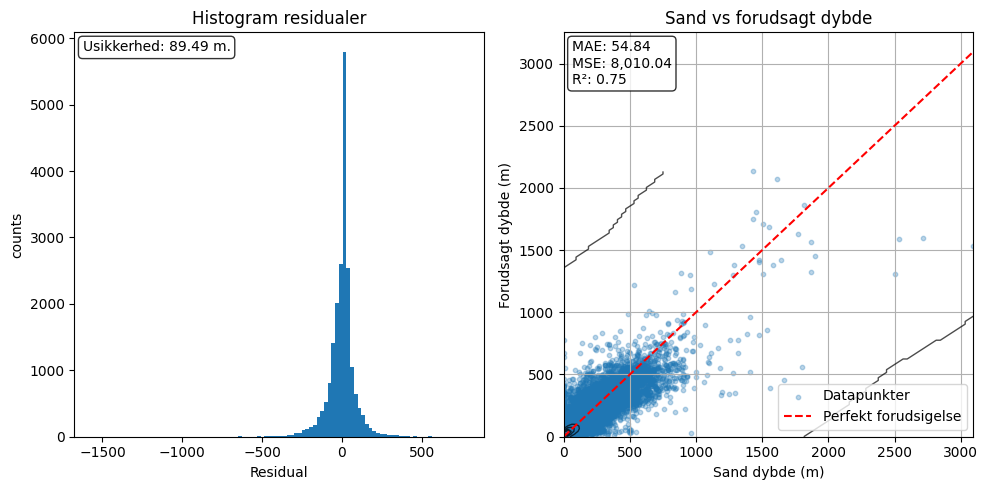

In [104]:
# Her definerer og træner vi modellen
mlp = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(layer_one, layer_two, layer_three, layer_four, layer_five, layer_six), 
max_iter=250, early_stopping=True, random_state=42)
mlp.fit(data_træning, sand_dybde_træning) 

# Her giver vi den trænede model test data som den ikke har set før, og beder om at forudsige dybden
forudsagt_dybde = mlp.predict(data_test)  

# Beregn antal parametre i modellen
# Coef er vægtene er intercept er bias. Den henter antallet direkte fra modellen.
n_params = sum(coef.size + intercept.size for coef, intercept in zip(mlp.coefs_, mlp.intercepts_))
print(f"Antal parametre i NN: {n_params}")

plotting(sand_dybde_test, forudsagt_dybde)

In [105]:
print("n_iter:", mlp.n_iter_)          # actual iterations performed
print("max_iter:", mlp.max_iter)
if mlp.n_iter_ < mlp.max_iter:
    print("MLPRegressor stopped early")
print("loss_curve (last values):", mlp.loss_curve_[-5:])
if hasattr(mlp, "validation_scores_"):
    print("validation_scores (last):", mlp.validation_scores_[-5:])

n_iter: 161
max_iter: 250
MLPRegressor stopped early
loss_curve (last values): [np.float64(3861.1214338781056), np.float64(3882.809362142169), np.float64(3897.0158201307027), np.float64(3894.154469202328), np.float64(3846.1626241971135)]
validation_scores (last): [0.7533689973075212, 0.7533387539820133, 0.7443809057386861, 0.7533772755882179, 0.7523767172070561]


### Spørsgmål:
- Prøv at justere på antal neuroner i det neurale netværk - Bliver modellen bedre dårligere/kører den hurtigere langsommere?
- Hvad sker der hvis du justerer max_iter?
- Får du det samme antal parametre når du regner efter?
- Hvilken algoritme klarer sig bedst? Boosted decision tree eller neutralt netværk? Kan du få NN til at klare sig lige så godt som BDT? Eller omvendt?
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?

### Avancerede spørgsmål:

Til hvis du vil bruge mere tid og finder ovenstående opgaver overskuelige.

- Leg rundt med hyperparametre (HP) i begge modeller (BDT og NN). Tilføj og fjern, ændr deres værdier, kør modellen og se hvordan den performer.  

    For BDT er nogen af dem:
    - num_leaves = integer (default = 31)    (hvor mange kasser seperate kasser må modellen maksimalt lave. )
    - boosting_type = 'gbdt', 'dart', 'rf' (default = 'gbdt') (Hvilken algoritme bruger vi til at booste)
    - max_depth = integer (default = -1 (negativt betyder ingen limit)) (hvor mange lag må der maksimalt være i vores træ)
    - learning_rate = integer (default = 0.1) (hvor store skridt modellen tager når den vil optimere loss function. Store skridt medfører den kan udforske mere, små skridt medfører den kan lave finere justeringer)
    - min_child_samples = integer (default = 20) (hvor mange samples skal der minimum være i en kasse)  
    Find hele listen af disse på: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html  
    
    For NN er nogen af dem:
    - activation = 'logistic', 'tanh', 'relu' (default = 'relu') (Hvilken activation function vil vi bruge for hvert lag)
    - learning_rate = 'constant', 'invscaling', 'adaptive' (default = 'constant') (hvordan opfører learning rate sig under træningens forløb, se forklaring ovenfor under BDT)
    - max_iter = integer (default = 200) (hvor mange iterationer af modellen skal vi køre for at optimere (kan sammenlignes med boosting_rounds for BDT))
    - alpha = decimal (default = 0.0001) (intern parameter i loss function som skal forhindre at modellen overfitter, dvs lærer træningsdata alt for godt at kende så man ikke længere kan anvende den på ny data)  
    Find hele listen af disse på: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html  



- Prøv at optimere modellen så du får den bedste performace (laveste MAE/MSE) ved at prøve forskellige kombinationer af HP af. Kan du komme i tanke op måder man ville kunne optimere/strukturere denne process på?  
- Slå sklearn's GridSearchCV og RandomizedSearchCV op og find ud af hvad de gør. Hvad er fordele/ulemper ved begge?
- Fjern early_stopping. Hvad gør det. Er det en fordel? Kan du risikere at overtræne hvis du ikke gør?
- Kør modellen på det store fulde datasæt. Hvilke parametre er der? Hvilke parametre er vigtige? Hvor meget data er der? Tager det længere tid?

- Er alle kolonner lige vigtige? Kør modellerne med kun de 5 bedste/værste variable og se deres performance. Nedenstående kode gør dette. 
Sæt denne ind lige efter cellen der "Inspicerer Data" og kør så hele filen igen.

In [ ]:
#På linjen under kan du vælge hvilke variable skal være med. Efterlad kun dem du vil bruge.
input_variabler = ['haeldning_300m', 'elevation', 'mass_balance', 'haeldning_adaptiv', 'hastighed_x', 'retning', 'hastighed_y', 'afstand_til_kant_km', 'areal']
variabler =  input_variabler + ['gletsjer_dybde']
selected_indices = [input_variabler.index(col) for col in input_variabler]
input_data = input_data[:, selected_indices]